In [1]:
# Core libs for file handling, arrays, dataframes, and plotting
import os  # filesystem paths and directory utilities
import numpy as np  # vectorized numerical ops
import pandas as pd  # tabular data handling
import seaborn as sns  # statistical plotting
sns.set_style('darkgrid')  # consistent dark grid background for plots
import matplotlib.pyplot as plt  # plotting primitives
from sklearn.model_selection import train_test_split  # dataset splitting helper
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)  # evaluation metrics

from PIL import Image  # image I/O and basic manipulation

# Deep learning stack (TensorFlow/Keras) and computer vision helpers
import tensorflow as tf  # core TensorFlow engine
from tensorflow import keras  # Keras high-level API
from tensorflow.keras.models import Sequential  # linear stack of layers
from tensorflow.keras.optimizers import Adam, Adamax  # optimizers
from tensorflow.keras.metrics import categorical_crossentropy  # loss metric alias
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # augmentation pipeline
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization  # layer building blocks
from tensorflow.keras import regularizers  # weight regularization
import cv2  # OpenCV for image processing
import warnings  # control warnings
from tqdm import tqdm  # progress bars

# Silence noisy warnings to keep notebook output clean
warnings.filterwarnings("ignore")

print('modules loaded')  # quick sanity check that imports succeeded

2026-03-18 22:18:16.818883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773872297.035488      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773872297.098107      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773872297.626743      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773872297.626817      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773872297.626820      24 computation_placer.cc:177] computation placer alr

modules loaded


## Dataset locations
Define dataset root paths for train/val/test splits.

In [2]:
from pathlib import Path
import os

# Get the dataset path
# dataset_path = kagglehub.dataset_download("kayiwarahim/colon-cancer")

dataset_path = "/kaggle/input/datasets/kayiwarahim/final-colon-dataset"
dataset_path = Path(dataset_path)

print(f"Dataset downloaded to: {dataset_path}")

train_path = os.path.join(dataset_path, "train")  # training images
val_path = os.path.join(dataset_path, "val")      # validation images
test_path = os.path.join(dataset_path, "test")    # test images

Dataset downloaded to: /kaggle/input/datasets/kayiwarahim/final-colon-dataset


## Re-split dataset to 70/20/10
Regenerate balanced train/val/test folders under `dataset_70_20_10`.

In [3]:
# Re-split existing dataset into 70/20/10 while preserving class balance
from pathlib import Path
import shutil

# source_root = '/kaggle/input/datasets/kayiwarahim/colon-cancer/dataset'
source_root = Path('/kaggle/input/datasets/kayiwarahim/final-colon-dataset/dataset')
# target_root = Path("dataset_70_20_10")
target_root = Path('/kaggle/working/dataset_70_20_10')

# start clean so counts don't accumulate on reruns
if target_root.exists():
    shutil.rmtree(target_root)

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

# collect all images per class across current splits
class_dirs = sorted(p.name for p in (source_root / "train").iterdir() if p.is_dir())
all_images = {cls: [] for cls in class_dirs}
for split in ["train", "val", "test"]:
    for cls in class_dirs:
        for img_path in (source_root / split / cls).glob("*"):
            if img_path.is_file():
                all_images[cls].append(img_path)

# split 70/20/10 using train_test_split for reproducibility
new_counts = {"train": {}, "val": {}, "test": {}}
for cls, imgs in all_images.items():
    train_imgs, tmp_imgs = train_test_split(imgs, test_size=0.3, random_state=42, shuffle=True)
    val_imgs, test_imgs = train_test_split(tmp_imgs, test_size=2/3, random_state=42, shuffle=True)
    split_map = {"train": train_imgs, "val": val_imgs, "test": test_imgs}

    for split, split_imgs in split_map.items():
        dest_dir = target_root / split / cls
        ensure_dir(dest_dir)
        for src in split_imgs:
            shutil.copy2(src, dest_dir / src.name)
        new_counts[split][cls] = len(split_imgs)

print("Re-split complete ->", target_root)
print("Counts per split:")
for split in ["train", "val", "test"]:
    print(split, new_counts[split])

# Point the rest of the notebook to the new split
dataset_path = str(target_root)
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

Re-split complete -> /kaggle/working/dataset_70_20_10
Counts per split:
train {'0_normal': 1050, '1_ulcerative_colitis': 1050, '2_polyps': 1050}
val {'0_normal': 150, '1_ulcerative_colitis': 150, '2_polyps': 150}
test {'0_normal': 300, '1_ulcerative_colitis': 300, '2_polyps': 300}


## Class list and counts
List class folders, tally images per split, and sanity-check balance.

In [4]:
# Inspect available class folders under the training split
classes = os.listdir(train_path)  # list class folder names inside train
print("Classes:", classes)  # show class labels detected

Classes: ['2_polyps', '0_normal', '1_ulcerative_colitis']


In [5]:
# Helper to count images per class inside a split folder
def count_images(folder):
    counts = {}  # accumulator for {class: count}
    for cls in os.listdir(folder):  # iterate class folders
        cls_path = os.path.join(folder, cls)  # full path to class dir
        counts[cls] = len(os.listdir(cls_path))  # number of files in class dir
    return counts

# Tally image counts across splits to check balance
train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: {'2_polyps': 1050, '0_normal': 1050, '1_ulcerative_colitis': 1050}
Validation: {'2_polyps': 150, '0_normal': 150, '1_ulcerative_colitis': 150}
Test: {'2_polyps': 300, '0_normal': 300, '1_ulcerative_colitis': 300}


## Visualize training distribution
Bar chart of class counts in the training split.

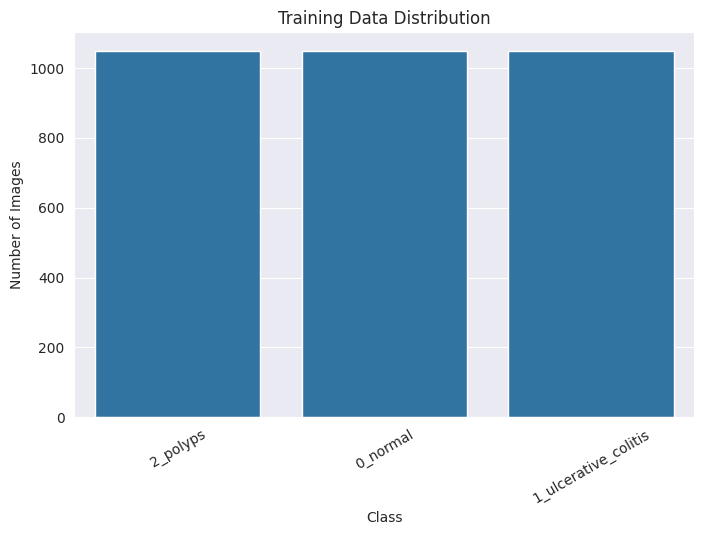

In [6]:
# Visualize class distribution in the training split
plt.figure(figsize=(8,5))  # set canvas size
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))  # bars for each class count
plt.title("Training Data Distribution")  # chart title
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)  # tilt labels for readability
plt.show()

In [7]:
# Build a dataframe listing every image with its split and label
records = []  # accumulator rows

for split in ['train','val','test']:
    split_path = os.path.join(dataset_path, split)  # current split folder

    for label in os.listdir(split_path):
        class_path = os.path.join(split_path, label)  # class folder path

        for img in os.listdir(class_path):
            records.append({
                "split": split,  # which split this file belongs to
                "label": label,  # class name
                "filepath": os.path.join(class_path, img)  # full file path
            })

eda_df = pd.DataFrame(records)  # assemble rows into dataframe

print("Total images:", len(eda_df))
eda_df.head()  # preview first rows

Total images: 4500


,split,label,filepath
0,train,2_polyps,/kaggle/working/dataset_70_20_10/train/2_polyp...
1,train,2_polyps,/kaggle/working/dataset_70_20_10/train/2_polyp...
2,train,2_polyps,/kaggle/working/dataset_70_20_10/train/2_polyp...
3,train,2_polyps,/kaggle/working/dataset_70_20_10/train/2_polyp...
4,train,2_polyps,/kaggle/working/dataset_70_20_10/train/2_polyp...


## Build EDA dataframe
Enumerate all files with split/label metadata for downstream analysis.

In [8]:
# Sample image dimensions to understand typical sizes
sizes = []  # holds (width, height) tuples

sample_paths = eda_df['filepath'].sample(200)  # random subset of images

for path in sample_paths:
    img = Image.open(path)  # open image
    sizes.append(img.size)  # record (width, height)

size_df = pd.DataFrame(sizes, columns=['width','height'])  # to analyze size distribution

print(size_df.describe())  # summary stats for width/height

             width       height
count   200.000000   200.000000
mean    689.780000   567.105000
std     129.412595    73.746094
min     437.000000   454.000000
25%     626.000000   531.000000
50%     720.000000   576.000000
75%     720.000000   576.000000
max    1920.000000  1072.000000


## Image dimension sampling
Sample image sizes to choose a sensible target resize.

In [9]:
# Inspect pixel value range on a sample image
sample_img = np.array(Image.open(eda_df['filepath'].iloc[0]))  # load first image into array

print("Min pixel value:", sample_img.min())  # darkest pixel
print("Max pixel value:", sample_img.max())  # brightest pixel

Min pixel value: 0
Max pixel value: 255


## Pixel range sanity check
Confirm images are in expected 0–255 range.

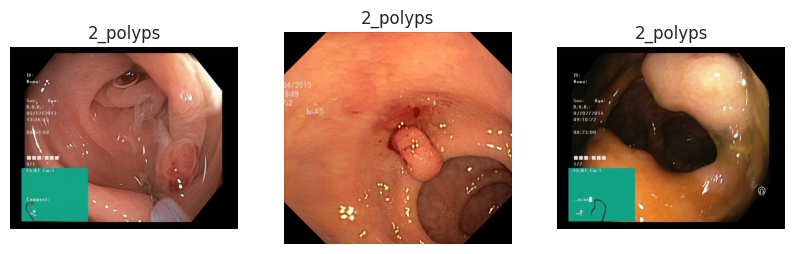

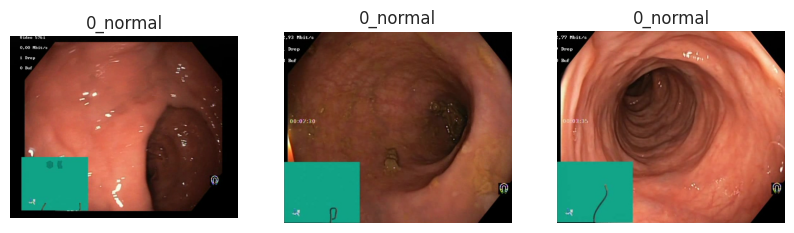

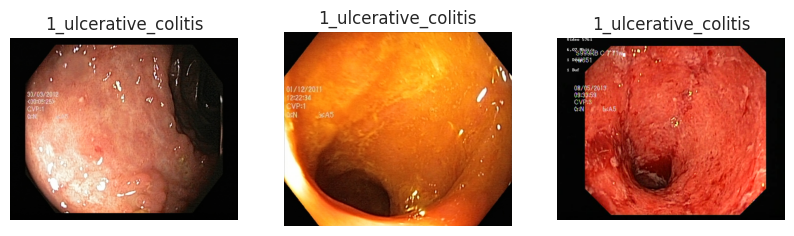

In [10]:
# Show a few example images per class to spot visual patterns
samples_per_class = 3  # images per label to display

for label in classes:
    class_path = os.path.join(train_path, label)  # folder for this label

    images = os.listdir(class_path)[:samples_per_class]  # pick first few files

    plt.figure(figsize=(10,3))  # one row of subplots

    for i, img_name in enumerate(images):
        img = cv2.imread(os.path.join(class_path, img_name))  # load with OpenCV (BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for plotting

        plt.subplot(1,3,i+1)  # select subplot slot
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")  # hide axes for clarity

    plt.show()

## Visual samples per class
Show a few images from each class to spot issues or patterns.

In [11]:
# Check for unreadable/corrupted images
broken = []  # collect paths that fail to open

for path in eda_df['filepath']:
    try:
        Image.open(path)  # attempt to open
    except:
        broken.append(path)  # record failures

print("Broken images:", len(broken))

Broken images: 0


## Corruption check
Attempt to open every file and flag unreadable images.

In [12]:
# Build a sampled stats dataframe capturing geometry, color, and texture features per image
tqdm.pandas()  # enable pandas integration for progress bars

# Sample a manageable subset to compute stats
stat_sample = eda_df.sample(min(len(eda_df), 600), random_state=42).reset_index(drop=True)  # limit to 600 for speed
stat_records = []  # feature rows

for _, row in tqdm(stat_sample.iterrows(), total=len(stat_sample)):
    img = Image.open(row['filepath']).convert('RGB')  # read image as RGB
    arr = np.array(img)  # to numpy
    h, w, _ = arr.shape  # spatial dims
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)  # grayscale version
    hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)  # HSV for brightness/saturation
    sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)  # edge response

    # Aggregate per-image stats for later plots
    stat_records.append({
        'split': row['split'],  # which split
        'label': row['label'],  # class
        'width': w,
        'height': h,
        'area': w * h,  # pixel count
        'aspect': w / h,  # width/height ratio
        'orientation': 'landscape' if w > h else ('portrait' if h > w else 'square'),
        'mean_r': arr[:, :, 0].mean(),  # average red
        'mean_g': arr[:, :, 1].mean(),  # average green
        'mean_b': arr[:, :, 2].mean(),  # average blue
        'brightness_v': hsv[:, :, 2].mean(),  # value channel mean
        'saturation_s': hsv[:, :, 1].mean(),  # saturation channel mean
        'contrast_gray': gray.std(),  # grayscale std as contrast proxy
        'edge_strength': np.mean(np.abs(sobel)),  # mean absolute edge magnitude
        'file_kb': os.path.getsize(row['filepath']) / 1024  # file size in KB
    })

stat_df = pd.DataFrame(stat_records)  # assemble feature table
stat_df['resolution'] = stat_df['width'].astype(str) + 'x' + stat_df['height'].astype(str)  # human-readable size

print(stat_df.head())
print('\nSample size used:', len(stat_df))

100%|██████████| 600/600 [00:06<00:00, 91.73it/s]

   split                 label  width  height    area    aspect orientation  \
0  train  1_ulcerative_colitis    623     529  329567  1.177694   landscape   
1   test              2_polyps    622     530  329660  1.173585   landscape   
2  train  1_ulcerative_colitis    628     530  332840  1.184906   landscape   
3  train  1_ulcerative_colitis    627     548  343596  1.144161   landscape   
4  train              2_polyps    588     528  310464  1.113636   landscape   

       mean_r      mean_g     mean_b  brightness_v  saturation_s  \
0  161.607549   87.373238  72.541935    161.621943    144.292156   
1  142.339550   75.845832  51.763541    142.385461    144.017096   
2  158.327058  102.494114  69.143459    173.298603    166.423723   
3  194.724377  101.702240  72.839646    194.779965    154.992477   
4  143.321912   80.907825  57.653477    143.364483    150.536336   

   contrast_gray  edge_strength     file_kb resolution  
0      62.512499      12.424933  274.992188    623x529  
1 

## Image-level feature extraction
Compute geometry, color, and texture stats on a sampled subset for downstream visuals.

**Why Visual 1 & 2 (count plots)**: Bar counts reveal whether splits or labels are imbalanced. They use seaborn `countplot` to tally rows from `eda_df`, showing split and class frequencies. Without these, we could miss data imbalance that skews training/validation and metrics.

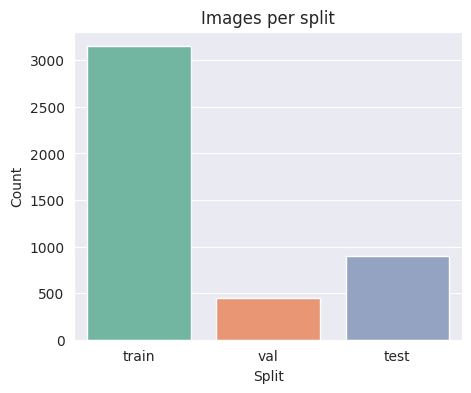

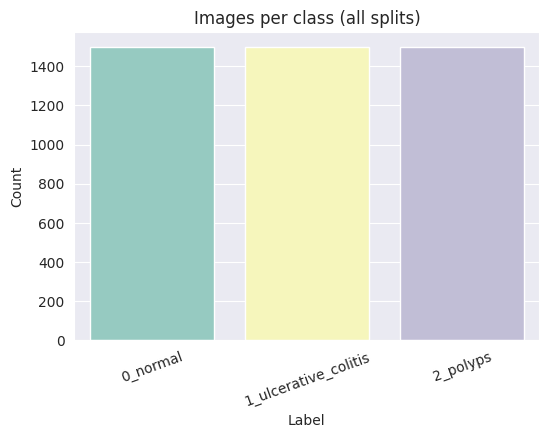

In [13]:
# Visual 1: overall split distribution
plt.figure(figsize=(5,4))  # compact bar chart
sns.countplot(data=eda_df, x='split', order=['train','val','test'], palette='Set2')  # bars per split
plt.title('Images per split')
plt.xlabel('Split')
plt.ylabel('Count')
plt.show()

# Visual 2: overall class distribution across all splits
plt.figure(figsize=(6,4))
sns.countplot(data=eda_df, x='label', order=sorted(eda_df['label'].unique()), palette='Set3')  # bars per label
plt.title('Images per class (all splits)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=20)  # tilt labels for readability
plt.show()

## Split and class distributions
Count plots for splits and labels to spot imbalance.

**Why Visual 3 & 4 (stacked/grouped bars)**: These compare class counts across train/val/test in one view using the precomputed `counts` table. Stacked shows total volume; grouped highlights per-split differences. Skipping them hides split-specific imbalance that can cause biased evaluation or sampling issues.

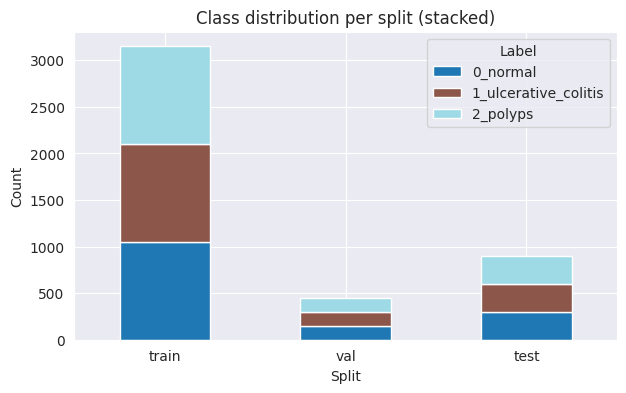

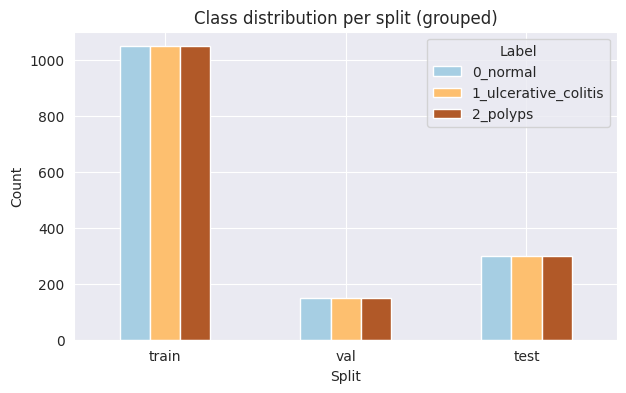

In [14]:
# Compare class counts per split using stacked and grouped bars
counts = eda_df.groupby(['split','label']).size().unstack(fill_value=0)[sorted(eda_df['label'].unique())]  # pivot counts
counts.loc[['train','val','test']].plot(kind='bar', stacked=True, figsize=(7,4), colormap='tab20')  # stacked view
plt.title('Class distribution per split (stacked)')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

counts.loc[['train','val','test']].plot(kind='bar', stacked=False, figsize=(7,4), colormap='Paired')  # grouped bars
plt.title('Class distribution per split (grouped)')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

## Split/class comparison
Stacked and grouped bars to compare class counts across splits.

**Why Visual 5 (heatmap)**: Heatmap of the `counts` matrix quickly spotlights over/under-represented class-split combos with color intensity. Without it, we rely on numbers alone and may overlook sparse cells that can cause poor generalization for specific classes in a split.

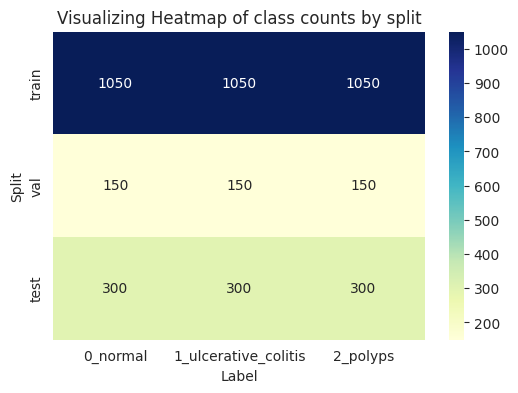

In [15]:
# Heatmap to highlight count imbalances across split/label
plt.figure(figsize=(6,4))
sns.heatmap(counts.loc[['train','val','test']], annot=True, fmt='d', cmap='YlGnBu')  # color-coded counts
plt.title('Visualizing Heatmap of class counts by split')
plt.xlabel('Label')
plt.ylabel('Split')
plt.show()

## Imbalance heatmap
Heatmap of class counts per split to highlight sparse cells.

**Why Visual 6 & 7 (pie charts)**: Pies summarize proportion of labels overall and splits overall, emphasizing share instead of counts. They make imbalance intuitive at a glance. Omitting them removes an easy percentage view; you’d rely on bar heights only, which can hide proportion differences when totals vary.

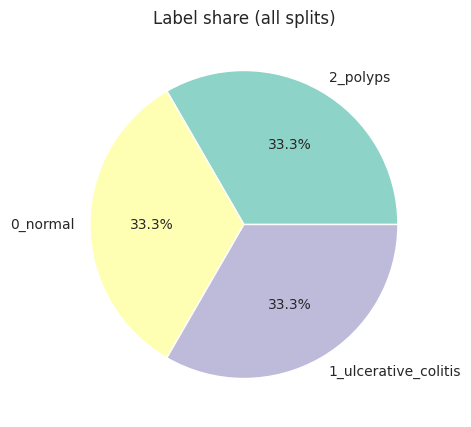

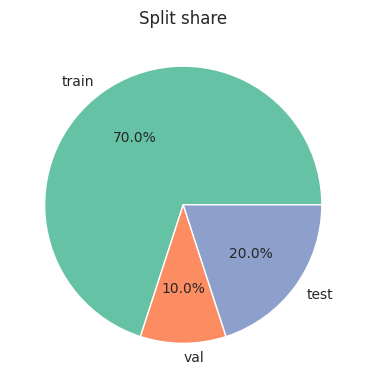

In [16]:
# Pie charts summarizing label and split proportions
plt.figure(figsize=(5,5))
eda_df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set3'))  # label share
plt.ylabel('')
plt.title('Label share (all splits)')
plt.show()

plt.figure(figsize=(4.5,4.5))
eda_df['split'].value_counts().reindex(['train','val','test']).plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set2'))  # split share
plt.ylabel('')
plt.title('Split share')
plt.show()

## Proportion pies
Pie charts to show label and split share as percentages.

**Why Visual 8 & 9 (width/height histograms)**: Histograms of dimensions show common image sizes and spread, guiding resize strategy. Without them we might choose an input size that crops or stretches many images, hurting model quality.

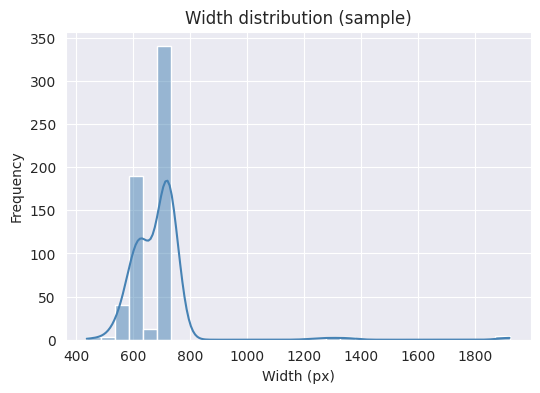

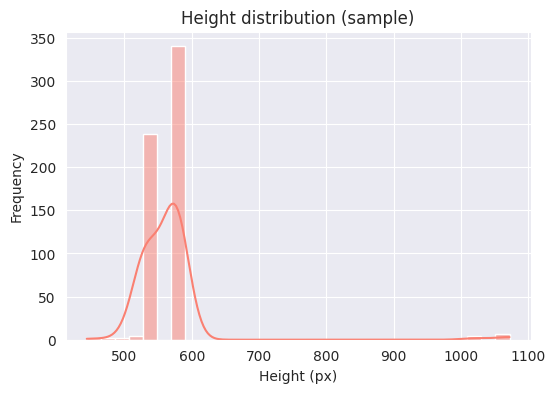

In [17]:
# Width and height distributions from sampled stats
plt.figure(figsize=(6,4))
sns.histplot(stat_df['width'], bins=30, color='steelblue', kde=True)  # histogram of widths
plt.title('Width distribution (sample)')
plt.xlabel('Width (px)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['height'], bins=30, color='salmon', kde=True)  # histogram of heights
plt.title('Height distribution (sample)')
plt.xlabel('Height (px)')
plt.ylabel('Frequency')
plt.show()

## Geometry histograms
Width and height distributions from sampled images.

**Why Visual 10 & 11 (hexbin + aspect histogram)**: Hexbin shows joint density of width vs height to spot typical resolutions and outliers; the aspect histogram shows shape tendencies. Skipping them hides whether sizes cluster along certain diagonals or if extreme aspect ratios need special handling.

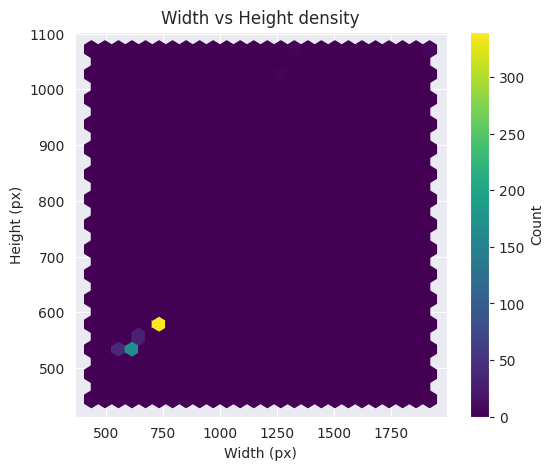

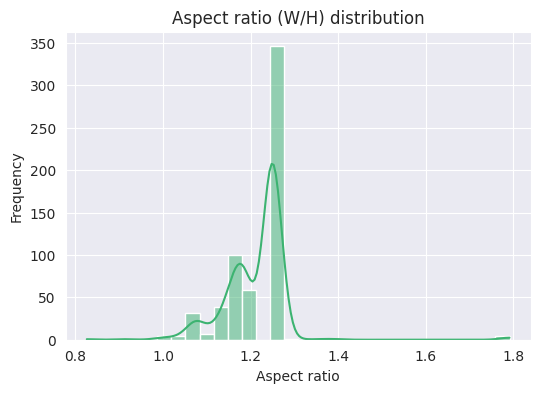

In [18]:
# Joint view of width vs height plus aspect ratio distribution
plt.figure(figsize=(6,5))
plt.hexbin(stat_df['width'], stat_df['height'], gridsize=25, cmap='viridis')  # 2D density of sizes
plt.title('Width vs Height density')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
cb = plt.colorbar()
cb.set_label('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['aspect'], bins=30, color='mediumseagreen', kde=True)  # aspect ratio distribution
plt.title('Aspect ratio (W/H) distribution')
plt.xlabel('Aspect ratio')
plt.ylabel('Frequency')
plt.show()

## Size density and aspect ratios
Hexbin of width/height and histogram of aspect ratios.

**Why Visual 12–14 (boxplots width/height/aspect by label)**: Boxplots compare geometry across classes to detect if one class has systematically different image sizes or shapes. Without them, class-specific preprocessing needs could be missed, leading to distortions for certain labels.

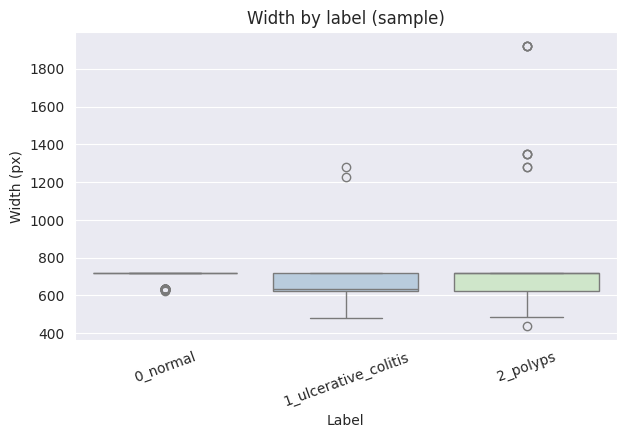

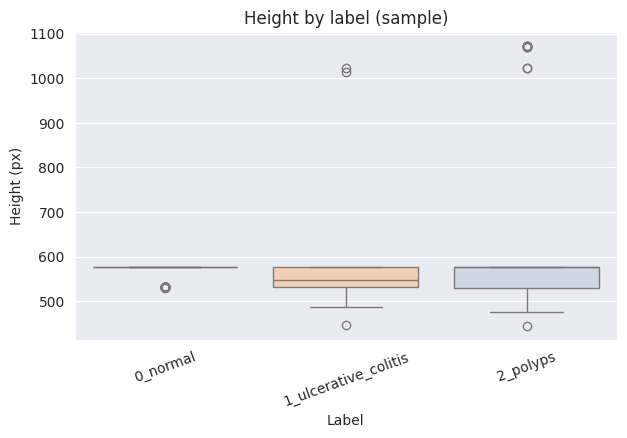

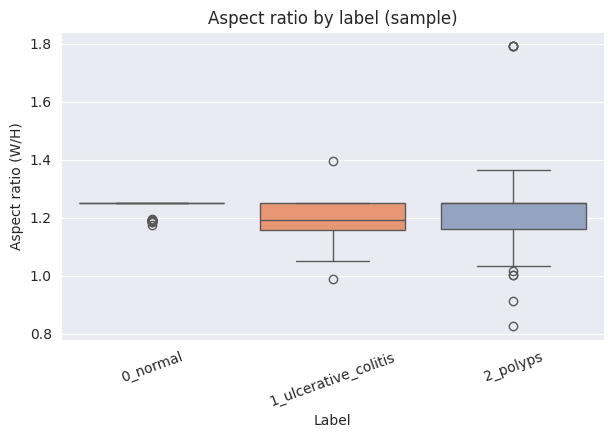

In [19]:
# Boxplots to compare geometry across labels
plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='width', order=sorted(stat_df['label'].unique()), palette='Pastel1')  # width per class
plt.title('Width by label (sample)')
plt.xlabel('Label')
plt.ylabel('Width (px)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='height', order=sorted(stat_df['label'].unique()), palette='Pastel2')  # height per class
plt.title('Height by label (sample)')
plt.xlabel('Label')
plt.ylabel('Height (px)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='aspect', order=sorted(stat_df['label'].unique()), palette='Set2')  # aspect ratio per class
plt.title('Aspect ratio by label (sample)')
plt.xlabel('Label')
plt.ylabel('Aspect ratio (W/H)')
plt.xticks(rotation=20)
plt.show()

## Geometry by label
Boxplots comparing width, height, and aspect ratio across classes.

**Why Visual 15 & 16 (orientation counts, area histogram)**: Orientation counts reveal dominant landscape/portrait mix, informing augmentation strategy; area histogram shows pixel count scale. Skipping them risks choosing crops/resize policies that penalize minority orientations or overwhelm memory with very large images.

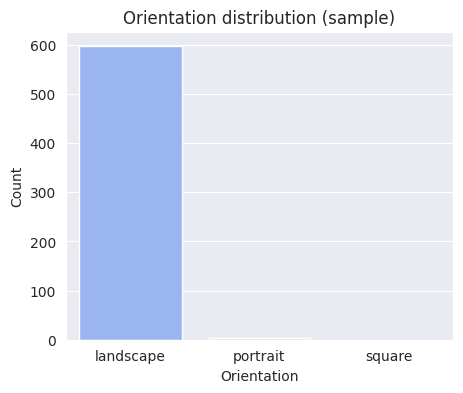

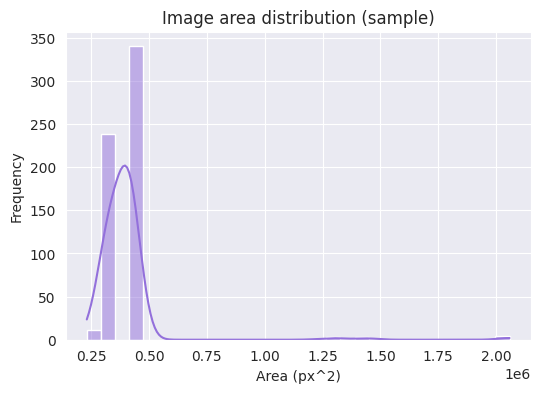

In [20]:
# Orientation mix and overall pixel area distribution
plt.figure(figsize=(5,4))
sns.countplot(data=stat_df, x='orientation', order=['landscape','portrait','square'], palette='coolwarm')  # orientation counts
plt.title('Orientation distribution (sample)')
plt.xlabel('Orientation')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['area'], bins=30, color='mediumpurple', kde=True)  # pixel area histogram
plt.title('Image area distribution (sample)')
plt.xlabel('Area (px^2)')
plt.ylabel('Frequency')
plt.show()

## Orientation and area
Orientation mix and pixel-area distribution to guide resizing/augmentation.

**Why Visual 17 (grayscale histogram)**: Sampling grayscale pixels shows contrast and brightness spread, indicating if normalization or CLAHE might help. Without it, we might miss low-contrast images that hinder edge detectors and CNN learning.

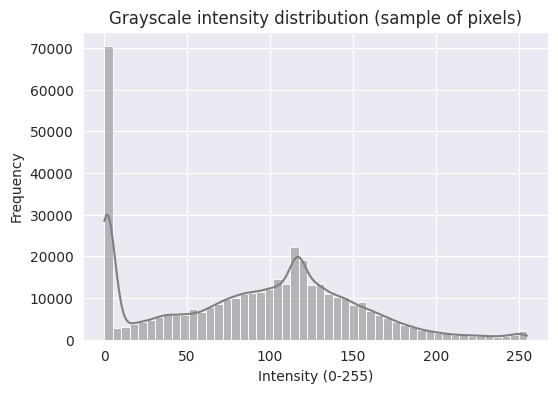

In [21]:
# Sample pixel intensities to see grayscale distribution
plt.figure(figsize=(6,4))
gray_values = []  # sampled grayscale pixels
for path in stat_sample['filepath'][:200]:  # limit to avoid huge arrays
    g = np.array(Image.open(path).convert('L')).flatten()  # grayscale pixels
    gray_values.extend(g[np.random.choice(len(g), size=min(2000, len(g)), replace=False)])  # random subset per image
sns.histplot(gray_values, bins=50, color='gray', kde=True)
plt.title('Grayscale intensity distribution (sample of pixels)')
plt.xlabel('Intensity (0-255)')
plt.ylabel('Frequency')
plt.show()

## Grayscale intensity
Histogram of sampled grayscale pixels to assess contrast/brightness spread.

**Why Visual 18 (mean RGB histograms)**: Shows distribution of per-image channel means, revealing color cast or illumination bias. Skipping it hides whether a color normalization step (e.g., per-channel standardization) is needed to stabilize training.

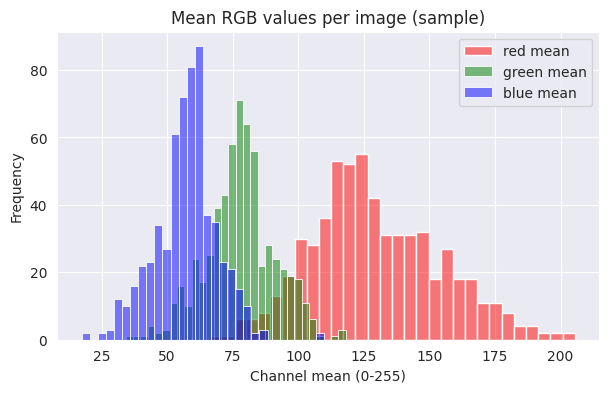

In [22]:
# Distribution of per-image mean RGB channels
plt.figure(figsize=(7,4))
channel_colors = ['red','green','blue']
for ch, color in enumerate(channel_colors):
    sns.histplot(stat_df[[f'mean_{c}' for c in ['r','g','b']][ch]], bins=30, color=color, label=f'{color} mean', alpha=0.5)  # channel mean histogram
plt.title('Mean RGB values per image (sample)')
plt.xlabel('Channel mean (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Mean RGB distribution
Channel-mean histograms to spot global color casts.

**Why Visual 19 (mean RGB per class)**: Class-level barplot checks if certain labels have systematic color differences, which might be discriminative or require balancing. Without it, we could miss color leakage cues or fail to apply augmentations that reduce over-reliance on color.

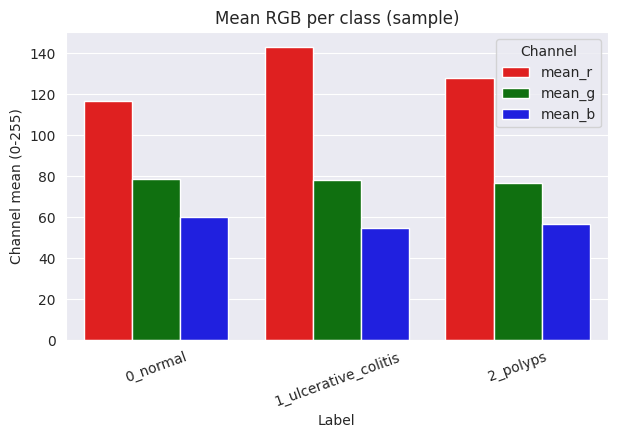

In [23]:
# Compare average RGB levels across classes
rgb_means = stat_df.groupby('label')[['mean_r','mean_g','mean_b']].mean().reset_index()  # per-class averages
rgb_melt = rgb_means.melt(id_vars='label', var_name='channel', value_name='mean_val')  # long format for seaborn
plt.figure(figsize=(7,4))
sns.barplot(data=rgb_melt, x='label', y='mean_val', hue='channel', palette={'mean_r':'red','mean_g':'green','mean_b':'blue'})
plt.title('Mean RGB per class (sample)')
plt.xlabel('Label')
plt.ylabel('Channel mean (0-255)')
plt.xticks(rotation=20)
plt.legend(title='Channel')
plt.show()

## Per-class color means
Barplot of mean RGB per class to detect color biases.

**Why Visual 20–23 (brightness/saturation/contrast/edges by label)**: Boxplots of V, S, gray std, and Sobel edge strength highlight per-class texture/lightness differences. Skipping them hides whether some classes are darker, less saturated, or smoother—factors that can cause biased feature learning or suggest preprocessing (e.g., histogram equalization, sharpening).

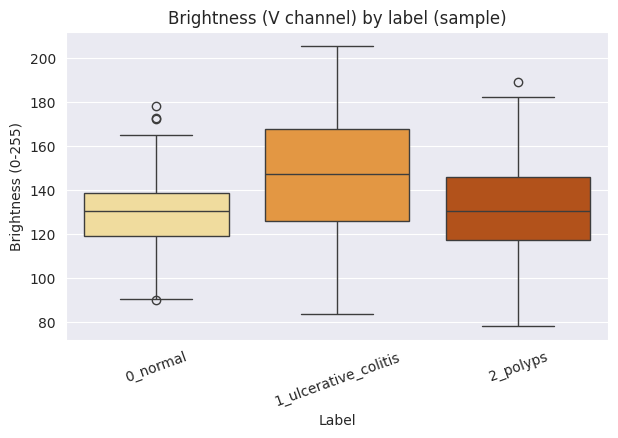

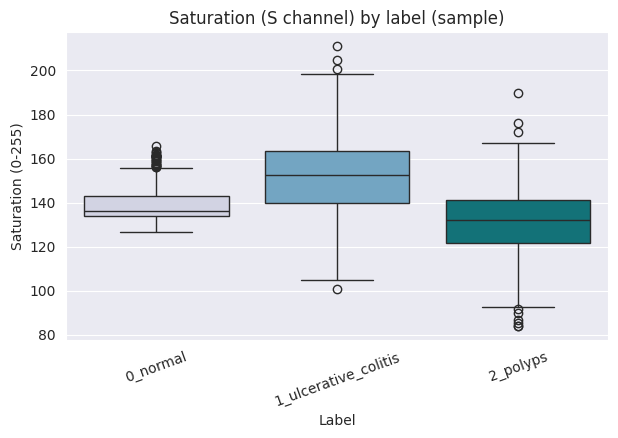

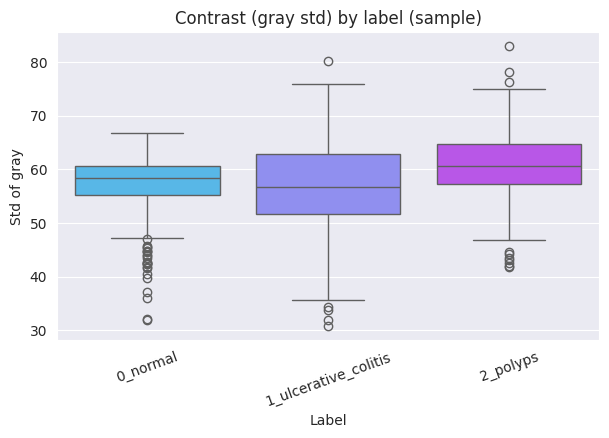

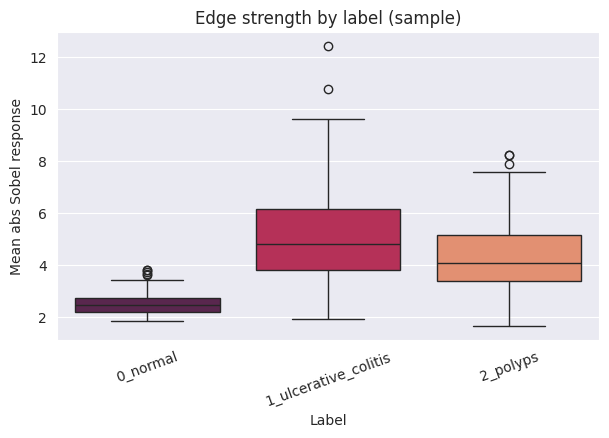

In [24]:
# Compare brightness, saturation, contrast, and edge strength per class
plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='brightness_v', order=sorted(stat_df['label'].unique()), palette='YlOrBr')  # V channel per class
plt.title('Brightness (V channel) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Brightness (0-255)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='saturation_s', order=sorted(stat_df['label'].unique()), palette='PuBuGn')  # saturation per class
plt.title('Saturation (S channel) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Saturation (0-255)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='contrast_gray', order=sorted(stat_df['label'].unique()), palette='cool')  # grayscale contrast per class
plt.title('Contrast (gray std) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Std of gray')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='edge_strength', order=sorted(stat_df['label'].unique()), palette='rocket')  # edge strength per class
plt.title('Edge strength by label (sample)')
plt.xlabel('Label')
plt.ylabel('Mean abs Sobel response')
plt.xticks(rotation=20)
plt.show()

## Brightness, saturation, texture by label
Boxplots for V/S channels, grayscale contrast, and edge strength across classes.

**Why Visual 24 & 25 (correlation heatmap, top resolutions)**: Correlation map shows relationships among numeric features (size, color, texture), guiding feature selection or decorrelation. Top-resolution bar plot surfaces the most common shapes to pick efficient resizing targets. Without these, we might choose redundant features or an inefficient canonical resolution, wasting compute or losing detail.

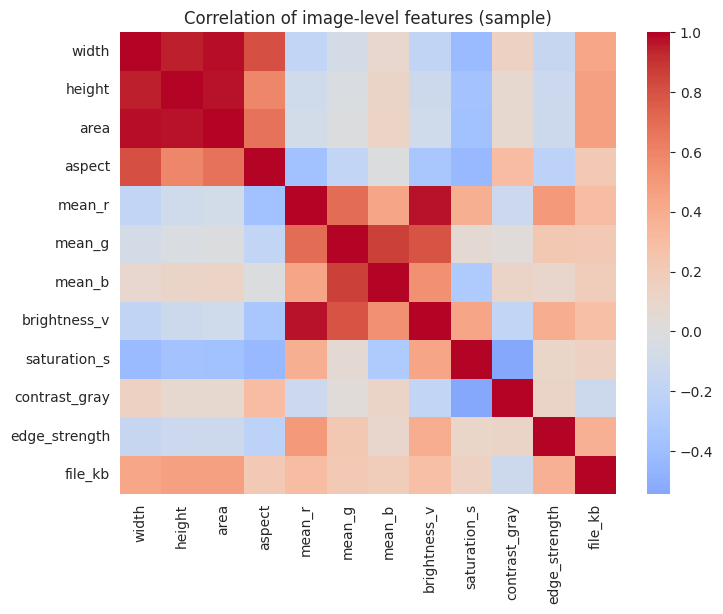

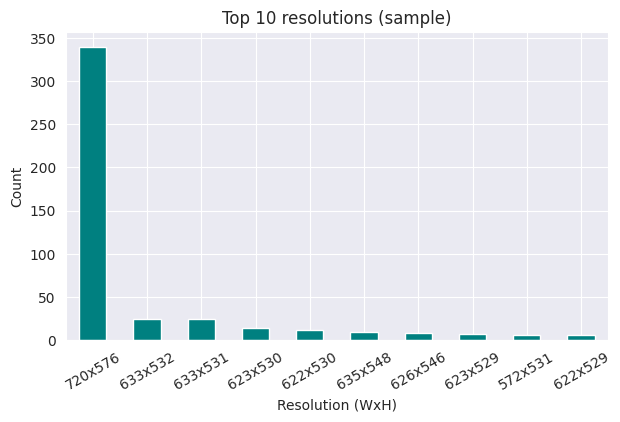

In [25]:
# Correlation across numeric features and most common resolutions
plt.figure(figsize=(8,6))
num_cols = ['width','height','area','aspect','mean_r','mean_g','mean_b','brightness_v','saturation_s','contrast_gray','edge_strength','file_kb']  # numeric feature list
corr = stat_df[num_cols].corr()  # correlation matrix
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)  # visualize correlations
plt.title('Correlation of image-level features (sample)')
plt.show()

plt.figure(figsize=(7,4))
stat_df['resolution'].value_counts().head(10).plot(kind='bar', color='teal')  # top resolutions
plt.title('Top 10 resolutions (sample)')
plt.xlabel('Resolution (WxH)')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

## Feature correlations and common resolutions
Correlation heatmap of numeric features plus most frequent resolutions.

In [26]:
# Image preprocessing: build train/val/test generators from active split
from pathlib import Path

action_root = Path("dataset_70_20_10") if Path("dataset_70_20_10").exists() else Path(dataset_path)
train_dir = action_root / "train"
val_dir = action_root / "val"
test_dir = action_root / "test"

img_size = (224, 224)
batch_size = 32

augment = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)
plain = ImageDataGenerator(rescale=1.0/255)

train_ds = augment.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
)
val_ds = plain.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
)
test_ds = plain.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
)

num_classes = len(train_ds.class_indices)
input_shape = img_size + (3,)
print("Generators ready from", action_root)

Found 3150 images belonging to 3 classes.
Found 450 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Generators ready from dataset_70_20_10


## Model training utilities
Shared helpers to compile, train, evaluate, and plot metrics for all architectures below.

In [27]:
# Keras training helper (shared across EfficientNet, ViT, and additional models)
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, VGG16, InceptionV3, MobileNetV2, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Simple utility to compile, train, and evaluate a Keras model
results = {}

def compile_and_train(model, label: str, epochs: int = 20):
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1,
    )
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"{label} -> test_acc={test_acc:.3f}, test_loss={test_loss:.3f}")
    results[label] = {"history": history.history, "test_acc": test_acc, "test_loss": test_loss}
    return results[label]


In [28]:
# Utility: plot training curves for a model in `results`

def plot_history(label: str, title: str = None):
    if label not in results or "history" not in results[label]:
        print(f"No history available for {label}; run training first.")
        return
    hist = results[label]["history"]
    acc = hist.get("accuracy", hist.get("acc", []))
    val_acc = hist.get("val_accuracy", hist.get("val_acc", []))
    loss = hist.get("loss", [])
    val_loss = hist.get("val_loss", [])
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="train_acc")
    plt.plot(epochs_range, val_acc, label="val_acc")
    plt.title(title or f"{label}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="train_loss")
    plt.plot(epochs_range, val_loss, label="val_loss")
    plt.title(title or f"{label}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(title or label)
    plt.tight_layout()
    plt.show()


### Evaluation utilities (accuracy, precision, recall, F1, AUC)
Helpers to score trained models on the held-out test set and visualize macro-averaged metrics.

In [29]:
# Compute test-set metrics (macro) and plot a comparison across models.

def evaluate_full_metrics(model, label: str):
    if model is None:
        print(f"{label}: model not provided.")
        return {}

    # Reset generator to ensure full sweep of test set before prediction.
    test_ds.reset()
    probs = model.predict(test_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true = test_ds.classes
    class_names = [cls for cls, idx in sorted(test_ds.class_indices.items(), key=lambda x: x[1])]
    y_true_one_hot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)

    acc = float((preds == y_true).mean())
    precision = float(precision_score(y_true, preds, average="macro", zero_division=0))
    recall = float(recall_score(y_true, preds, average="macro", zero_division=0))
    f1 = float(f1_score(y_true, preds, average="macro", zero_division=0))
    try:
        auc = float(roc_auc_score(y_true_one_hot, probs, average="macro", multi_class="ovr"))
    except ValueError:
        auc = float("nan")

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
    }

    results.setdefault(label, {}).update(
        {
            "metrics": metrics,
            "class_names": class_names,
            "y_true": y_true.tolist(),
            "y_pred": preds.tolist(),
        }
    )
    return metrics


def evaluate_and_plot(model_map: dict):
    rows = []
    for lbl, model in model_map.items():
        metrics = evaluate_full_metrics(model, lbl)
        if metrics:
            rows.append({"model": lbl, **metrics})

    if not rows:
        print("No trained models were supplied; train models first.")
        return pd.DataFrame()

    df = pd.DataFrame(rows).set_index("model")
    display(df)

    ax = df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
    ax.set_title("Test metrics by model (macro averages)")
    ax.set_ylabel("Score (0-1)")
    ax.set_xlabel("Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return df

## CNN baseline
Build, train, plot, and save a simple convolutional baseline to benchmark transfer models.

### CNN baseline — define architecture
Construct a small CNN with batch norm and dropout to act as a baseline classifier.

In [30]:
# Define CNN baseline

# Builds a shallow convolutional classifier with batch norm regularization.
def make_cnn_baseline():
    model = Sequential(name="CNN_baseline")
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation="softmax"))
    return model


I0000 00:00:1773872470.980906      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773872470.986928      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Saved successfully at: images/cnn_baseline_architecture.png


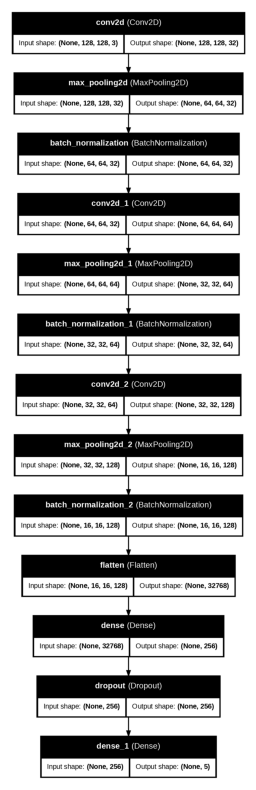

In [31]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
from PIL import Image

# Keep visualization settings local so training globals are not overwritten.
viz_input_shape = (128, 128, 3)
viz_num_classes = 5

# Create image directory if it does not exist
os.makedirs("images", exist_ok=True)

def make_cnn_baseline_preview():
    model = Sequential(name="CNN_baseline_preview")
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=viz_input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.4))
    model.add(Dense(viz_num_classes, activation="softmax"))
    return model

cnn_preview_model = make_cnn_baseline_preview()
cnn_preview_model.build((None, *viz_input_shape))

# Save into images directory
image_path = "images/cnn_baseline_architecture.png"

try:
    plot_model(
        cnn_preview_model,
        to_file=image_path,
        show_shapes=True,
        show_layer_names=True,
        dpi=150
    )

    if os.path.exists(image_path):
        print(f"Saved successfully at: {image_path}")

        img = Image.open(image_path)
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    else:
        print("plot_model ran, but no image file was created.")

except Exception as e:
    print("Error while generating model image:")
    print(e)

### CNN baseline — train and evaluate
Instantiate the CNN, train for a placeholder epoch, and log the test metrics.

In [32]:
# Train CNN baseline
# Set placeholder epochs; increase later for real training.
epochs = 20
cnn_model = make_cnn_baseline()
cnn_results = compile_and_train(cnn_model, "cnn_baseline", epochs=epochs)

# Quick view of accumulated test metrics for all trained models.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


Epoch 1/20


I0000 00:00:1773872477.608371      98 service.cc:152] XLA service 0x7fceb0012c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773872477.608406      98 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773872477.608410      98 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773872478.186574      98 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/99 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.4219 - loss: 2.2105  

I0000 00:00:1773872484.970687      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 482ms/step - accuracy: 0.7531 - loss: 1.0336 - val_accuracy: 0.3333 - val_loss: 1.2604
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 430ms/step - accuracy: 0.8637 - loss: 0.3286 - val_accuracy: 0.3333 - val_loss: 2.7450
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 418ms/step - accuracy: 0.8829 - loss: 0.2964 - val_accuracy: 0.5244 - val_loss: 1.7089
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 422ms/step - accuracy: 0.8925 - loss: 0.2441 - val_accuracy: 0.6333 - val_loss: 1.3772
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.9090 - loss: 0.2216 - val_accuracy: 0.9000 - val_loss: 0.2176
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.9080 - loss: 0.2092 - val_accuracy: 0.9156 - val_loss: 0.1981
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - accuracy: 0.9268 - loss: 0.1800 - val_accuracy: 0.9178 - val_loss: 0.1632
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 425ms/step - accuracy: 0.9327 - loss: 0.1518 - val_accuracy: 0.940

### CNN baseline plot learning curves
Visualize train/val accuracy and loss for the CNN baseline.

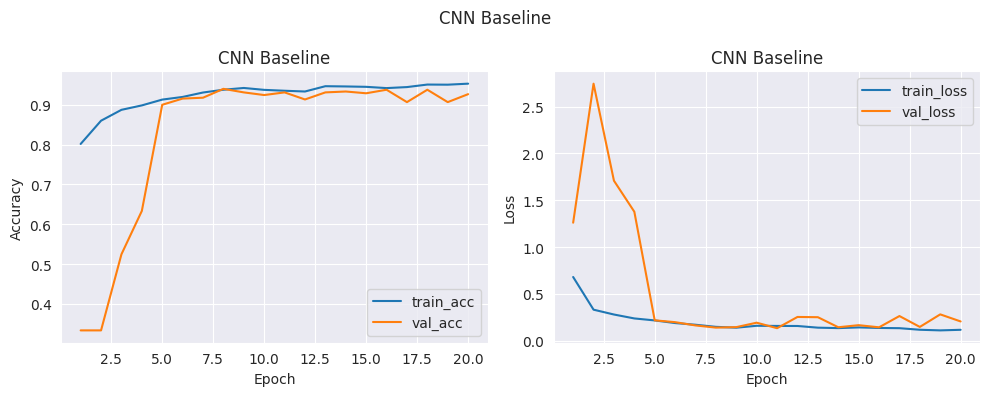

In [33]:
# Plot CNN baseline training curves
# Uses shared helper to draw accuracy/loss for this run.
plot_history("cnn_baseline", title="CNN Baseline")


### CNN baseline — save weights
Persist the trained CNN baseline to disk for later use.

In [34]:
# Save CNN baseline model
from pathlib import Path

# Ensure models directory exists then save the baseline weights.
Path("models").mkdir(exist_ok=True)
cnn_model.save("models/cnn_baseline.h5")
print("Saved CNN baseline to models/cnn_baseline.h5")


Saved CNN baseline to models/cnn_baseline.h5


## EfficientNetB0
Freeze the ImageNet backbone, add a small head, then train, plot curves, and save the model.

### EfficientNetB0 — define architecture
Freeze EfficientNetB0 backbone and attach a small dense head for classification.

In [35]:
# Define EfficientNetB0

# Use ImageNet-pretrained EfficientNetB0 as frozen feature extractor with a custom head.
def make_efficientnet_b0():
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="EfficientNetB0_frozen")


### EfficientNetB0  train and evaluate
Instantiate EfficientNetB0 classifier, run placeholder epoch, and log metrics.
Use shared plotting helper to visualize EfficientNetB0 training history.

In [36]:
# Train EfficientNetB0
# Set placeholder epochs; adjust upward for full training.
epochs = 20
EffNetB0_model = make_efficientnet_b0()
eff_results = compile_and_train(EffNetB0_model, "efficientnet_b0", epochs=epochs)

# Show cumulative test metrics from all runs so far.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-03-18 22:36:12.258643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:36:12.402354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:36:12.753325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:36:12.894064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:36:13.626824: E external/local_xla/xla/stream_

81/99 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.3129 - loss: 1.1183

2026-03-18 22:37:00.759037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:00.898488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:01.216545: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:01.357625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:02.081452: E external/local_xla/xla/stream_

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.3127 - loss: 1.1178

2026-03-18 22:37:28.540617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:28.675025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:28.982955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:29.123616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:37:29.832811: E external/local_xla/xla/stream_

99/99 ━━━━━━━━━━━━━━━━━━━━ 99s 742ms/step - accuracy: 0.3127 - loss: 1.1178 - val_accuracy: 0.3333 - val_loss: 1.1001
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 433ms/step - accuracy: 0.3297 - loss: 1.1072 - val_accuracy: 0.3333 - val_loss: 1.1023
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 44s 440ms/step - accuracy: 0.3080 - loss: 1.1075 - val_accuracy: 0.3333 - val_loss: 1.1008
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 436ms/step - accuracy: 0.3454 - loss: 1.1012 - val_accuracy: 0.3889 - val_loss: 1.1012
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 44s 439ms/step - accuracy: 0.3295 - loss: 1.1042 - val_accuracy: 0.3333 - val_loss: 1.0993
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 435ms/step - accuracy: 0.3172 - loss: 1.1021 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 420ms/step - accuracy: 0.3227 - loss: 1.1010 - val_accuracy: 0.3333 - val_loss: 1.0985
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 422ms/step - accuracy: 0.3357 - loss: 1.1007 - val_accuracy: 0.333

2026-03-18 22:51:10.471880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:51:10.606682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:51:10.912994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:51:11.053080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 22:51:11.753157: E external/local_xla/xla/stream_

efficientnet_b0 -> test_acc=0.333, test_loss=1.099
{'cnn_baseline': {'test_acc': 0.939, 'test_loss': 0.275}, 'efficientnet_b0': {'test_acc': 0.333, 'test_loss': 1.099}}


### EfficientNetB0 — plot learning curves
Plot accuracy and loss for the EfficientNetB0 run via the shared helper.

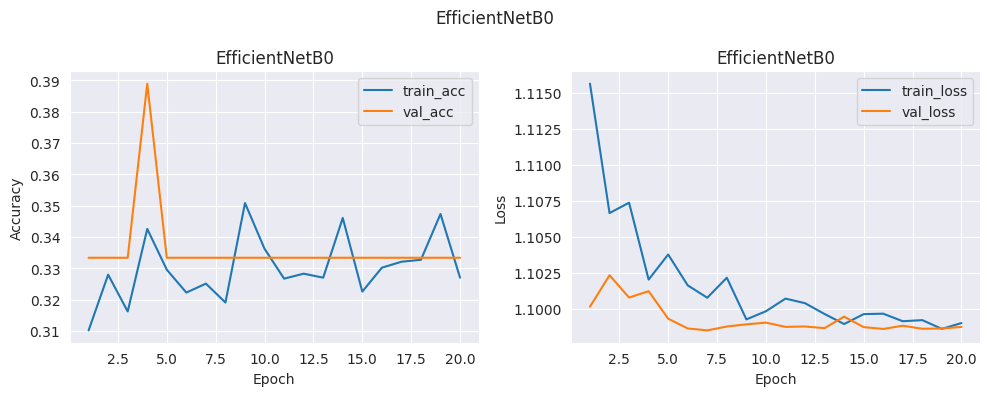

In [37]:
# Plot EfficientNetB0 training curves
# Helper plots accuracy and loss across epochs.
plot_history("efficientnet_b0", title="EfficientNetB0")


### EfficientNetB0 — save weights
Save the trained EfficientNetB0 model to disk.

In [38]:
# Save EfficientNetB0 Keras model
from pathlib import Path

# Persist EfficientNetB0 weights.
Path("models").mkdir(exist_ok=True)
EffNetB0_model.save("models/efficientnet_b0.h5")
print("Saved EfficientNetB0 to models/efficientnet_b0.h5")


Saved EfficientNetB0 to models/efficientnet_b0.h5


## DenseNet121
Use a frozen DenseNet121 feature extractor, fine-tune the classifier head, visualize training, and save.

### DenseNet121 — define architecture
Freeze DenseNet121 features and attach a compact classifier head.

In [39]:
# Define DenseNet121

# Use ImageNet-pretrained DenseNet121 frozen as feature extractor with custom classifier head.
def make_densenet121():
    base = DenseNet121(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="DenseNet121_frozen")


### DenseNet121 — train and evaluate
Create the DenseNet121 model, run one epoch placeholder training, and record metrics.

In [40]:
# Train DenseNet121
# Placeholder epochs value; increase for full runs.
epochs = 20
densenet_model = make_densenet121()
densenet_results = compile_and_train(densenet_model, "densenet121", epochs=epochs)

# Display summary metrics accumulated so far.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 103s 767ms/step - accuracy: 0.6090 - loss: 0.8817 - val_accuracy: 0.8956 - val_loss: 0.3236
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 424ms/step - accuracy: 0.8825 - loss: 0.3435 - val_accuracy: 0.9422 - val_loss: 0.1885
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 424ms/step - accuracy: 0.9246 - loss: 0.2449 - val_accuracy: 0.9556 - val_loss: 0.1424
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.9399 - loss: 0.1821 - val_accuracy: 0.9511 - val_loss: 0.1453
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 420ms/step - accuracy: 0.9582 - loss: 0.1544 - val_accuracy: 0.9533 - val_loss: 0.1170
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.9555 - loss: 0.1362 - val_accuracy: 0.9689 - val_loss: 0.0963
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 419ms/step - accuracy: 0.9559 - loss: 0.1290 - val_accuracy: 0.9622 - val_loss: 0.0973
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 419

### DenseNet121 — plot learning curves
Plot accuracy and loss for the DenseNet121 run via the shared helper.

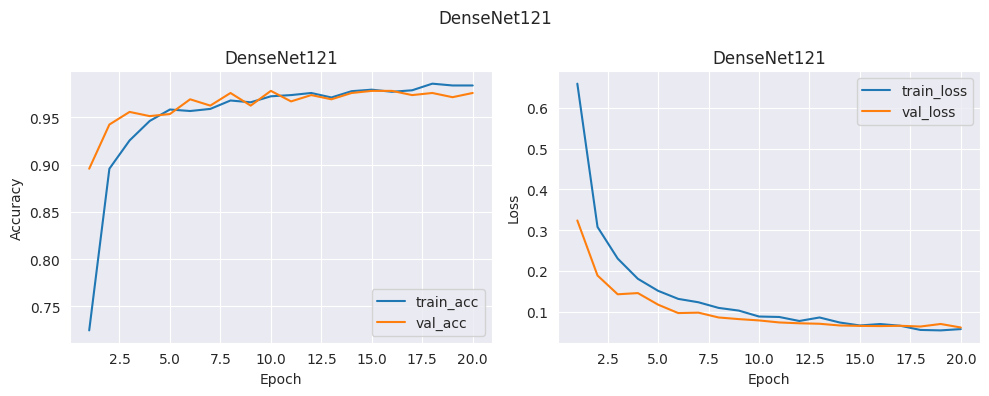

In [41]:
# Plot DenseNet121 training curves
# Visualize training and validation metrics for DenseNet121.
plot_history("densenet121", title="DenseNet121")


### DenseNet121 — save weights
Store the DenseNet121 model after training.

In [42]:
# Save DenseNet121 model
from pathlib import Path

# Persist the trained DenseNet121 weights.
Path("models").mkdir(exist_ok=True)
densenet_model.save("models/densenet121.h5")
print("Saved DenseNet121 to models/densenet121.h5")


Saved DenseNet121 to models/densenet121.h5


## VGG16
Train a frozen VGG16 backbone with a lightweight head, plot accuracy/loss, and persist the weights.

### VGG16 — define architecture
Freeze VGG16 convolutional base and attach a custom dense classifier.

In [43]:
# Define VGG16

# Use pretrained VGG16 frozen as a feature extractor with a small dense head.
def make_vgg16():
    base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="VGG16_frozen")


### VGG16 — train and evaluate
Instantiate VGG16 classifier, run placeholder epoch, and capture metrics.

In [44]:
# Train VGG16
# Placeholder epochs value; increase when ready to train longer.
epochs = 20
vgg16_model = make_vgg16()
vgg16_results = compile_and_train(vgg16_model, "vgg16", epochs=epochs)

# Report metrics across all trained models.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 74s 583ms/step - accuracy: 0.3744 - loss: 1.1516 - val_accuracy: 0.6689 - val_loss: 0.9395
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.5753 - loss: 0.9357 - val_accuracy: 0.7489 - val_loss: 0.8066
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 474ms/step - accuracy: 0.6948 - loss: 0.8053 - val_accuracy: 0.7733 - val_loss: 0.7065
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 468ms/step - accuracy: 0.7372 - loss: 0.7188 - val_accuracy: 0.7622 - val_loss: 0.6413
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 458ms/step - accuracy: 0.7934 - loss: 0.6309 - val_accuracy: 0.8267 - val_loss: 0.5734
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 463ms/step - accuracy: 0.7998 - loss: 0.5785 - val_accuracy: 0.8333 - val_loss: 0.5263
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 468ms/step - accuracy: 0.8218 - loss: 0.5302 - val_accuracy: 0.8356 - val_loss: 0.4893
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 461m

### VGG16 — plot learning curves
Plot train/val accuracy and loss for the VGG16 run.

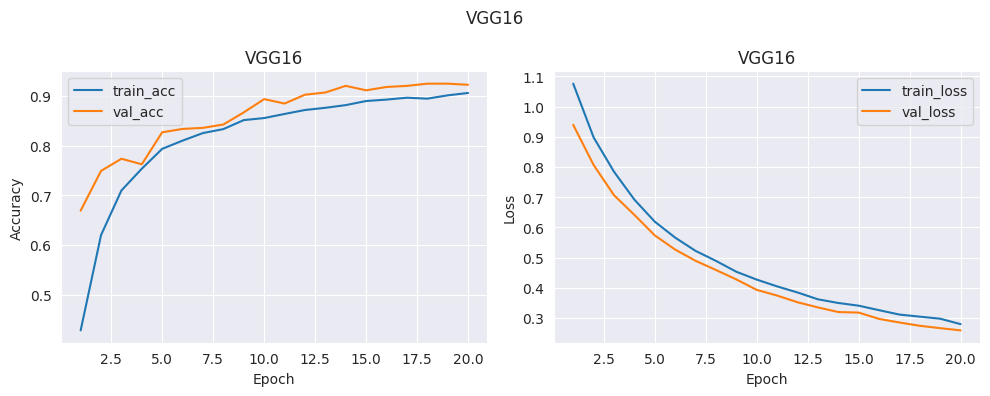

In [45]:
# Plot VGG16 training curves
# Visualize training/validation accuracy and loss for VGG16.
plot_history("vgg16", title="VGG16")


### VGG16 — save weights
Save the trained VGG16 model to disk.

In [46]:
# Save VGG16 model
from pathlib import Path

# Persist VGG16 weights for later inference.
Path("models").mkdir(exist_ok=True)
vgg16_model.save("models/vgg16.h5")
print("Saved VGG16 to models/vgg16.h5")


Saved VGG16 to models/vgg16.h5


## InceptionV3
Leverage InceptionV3 features with a custom head, track training curves, and save the model.

### InceptionV3 — define architecture
Freeze InceptionV3 base and add a compact classifier head.

In [47]:
# Define InceptionV3

# Use pretrained InceptionV3 frozen as feature extractor with a dense head.
def make_inception_v3():
    base = InceptionV3(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="InceptionV3_frozen")


### InceptionV3 — train and evaluate
Instantiate InceptionV3 classifier, run one-epoch placeholder training, and print metrics.

In [48]:
# Train InceptionV3
# Placeholder epochs value; increase later for better convergence.
epochs = 20
inception_model = make_inception_v3()
inception_results = compile_and_train(inception_model, "inception_v3", epochs=epochs)

# Display current metrics table.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 74s 598ms/step - accuracy: 0.6325 - loss: 0.7784 - val_accuracy: 0.9022 - val_loss: 0.2962
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.8810 - loss: 0.3124 - val_accuracy: 0.9222 - val_loss: 0.2102
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 419ms/step - accuracy: 0.9146 - loss: 0.2253 - val_accuracy: 0.9422 - val_loss: 0.1938
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.9279 - loss: 0.1920 - val_accuracy: 0.9467 - val_loss: 0.1608
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 433ms/step - accuracy: 0.9410 - loss: 0.1726 - val_accuracy: 0.9511 - val_loss: 0.1530
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 436ms/step - accuracy: 0.9489 - loss: 0.1437 - val_accuracy: 0.9533 - val_loss: 0.1411
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 438ms/step - accuracy: 0.9496 - loss: 0.1458 - val_accuracy: 0.9467 - val_loss: 0.1406
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 43s 436m

### InceptionV3 — plot learning curves
Plot accuracy/loss for the InceptionV3 run using the shared helper.

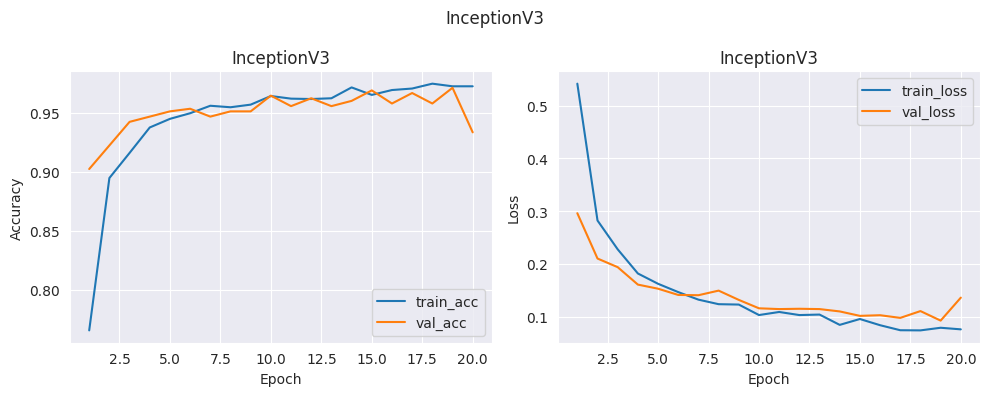

In [49]:
# Plot InceptionV3 training curves
# Visualize train/validation metrics for InceptionV3.
plot_history("inception_v3", title="InceptionV3")


### InceptionV3 — save weights
Save the trained InceptionV3 model to disk.

In [50]:
# Save InceptionV3 model
from pathlib import Path

# Persist trained InceptionV3 weights.
Path("models").mkdir(exist_ok=True)
inception_model.save("models/inception_v3.h5")
print("Saved InceptionV3 to models/inception_v3.h5")


Saved InceptionV3 to models/inception_v3.h5


## ResNet50
Train and evaluate a frozen ResNet50 backbone with a dense head, plot performance, and save the artifact.

### ResNet50 — define architecture
Freeze ResNet50 backbone and add a dense head for classification.

In [51]:
# Define ResNet50

# Use pretrained ResNet50 frozen as feature extractor with a dense head.
def make_resnet50():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="ResNet50_frozen")


### ResNet50 — train and evaluate
Instantiate ResNet50 classifier, run one epoch placeholder, and log metrics.

In [52]:
# Train ResNet50
# Placeholder epochs value; bump up when ready for longer training.
epochs = 20
resnet_model = make_resnet50()
resnet_results = compile_and_train(resnet_model, "resnet50", epochs=epochs)

# Display cumulative metrics across models.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 65s 528ms/step - accuracy: 0.3303 - loss: 1.2739 - val_accuracy: 0.4800 - val_loss: 1.0711
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.3551 - loss: 1.1283 - val_accuracy: 0.5133 - val_loss: 1.0461
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.3896 - loss: 1.0895 - val_accuracy: 0.5578 - val_loss: 1.0178
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 417ms/step - accuracy: 0.4091 - loss: 1.0668 - val_accuracy: 0.6022 - val_loss: 0.9962
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.4671 - loss: 1.0416 - val_accuracy: 0.5489 - val_loss: 0.9758
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 421ms/step - accuracy: 0.4866 - loss: 1.0219 - val_accuracy: 0.6089 - val_loss: 0.9519
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 413ms/step - accuracy: 0.5293 - loss: 1.0081 - val_accuracy: 0.6044 - val_loss: 0.9356
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 415m

### ResNet50 — plot learning curves
Plot accuracy and loss for the ResNet50 run using the helper.

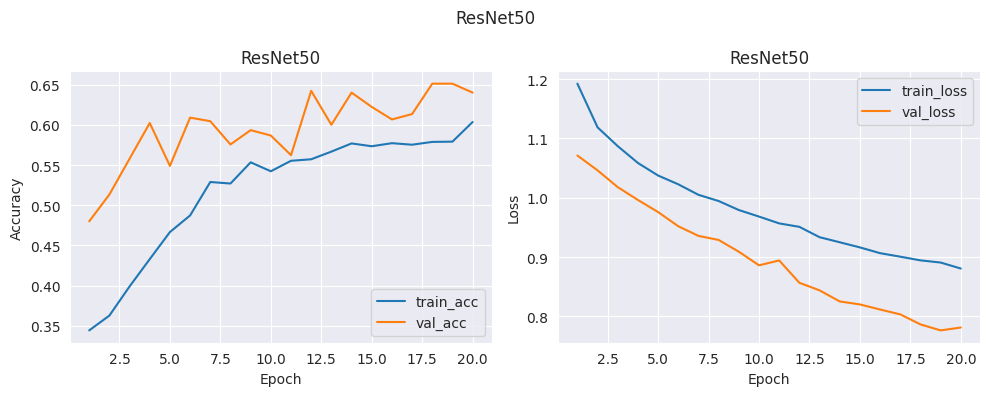

In [53]:
# Plot ResNet50 training curves
# Visualize training/validation metrics for ResNet50.
plot_history("resnet50", title="ResNet50")


### ResNet50 — save weights
Save the trained ResNet50 model to disk.

In [54]:
# Save ResNet50 model
from pathlib import Path

# Persist ResNet50 weights for later inference.
Path("models").mkdir(exist_ok=True)
resnet_model.save("models/resnet50.h5")
print("Saved ResNet50 to models/resnet50.h5")


Saved ResNet50 to models/resnet50.h5


## MobileNetV2
Train a lightweight MobileNetV2 classifier head, inspect learning curves, and save for reuse.

### MobileNetV2 — define architecture
Freeze MobileNetV2 backbone and attach a lightweight dense head.

In [55]:
# Define MobileNetV2

# Use pretrained MobileNetV2 frozen as feature extractor with a dense classification head.
def make_mobilenet_v2():
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base.input, outputs=out, name="MobileNetV2_frozen")


### MobileNetV2 — train and evaluate
Instantiate MobileNetV2 classifier, run one epoch, and show metrics.

In [56]:
# Train MobileNetV2
# Placeholder epochs; increase for proper training.
epochs = 20
mobilenet_model = make_mobilenet_v2()
mobilenet_results = compile_and_train(mobilenet_model, "mobilenet_v2", epochs=epochs)

# Print consolidated metrics across models.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-03-18 23:52:44.617182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 23:52:44.754872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 6/99 ━━━━━━━━━━━━━━━━━━━━ 30s 331ms/step - accuracy: 0.3519 - loss: 1.1994

2026-03-18 23:52:54.800378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 23:52:54.937332: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.6608 - loss: 0.7586

2026-03-18 23:53:45.391873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 23:53:45.527829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


99/99 ━━━━━━━━━━━━━━━━━━━━ 73s 611ms/step - accuracy: 0.6622 - loss: 0.7561 - val_accuracy: 0.9400 - val_loss: 0.2023
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 419ms/step - accuracy: 0.9095 - loss: 0.2482 - val_accuracy: 0.9622 - val_loss: 0.1254
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.9490 - loss: 0.1770 - val_accuracy: 0.9533 - val_loss: 0.1218
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - accuracy: 0.9484 - loss: 0.1471 - val_accuracy: 0.9711 - val_loss: 0.0796
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 413ms/step - accuracy: 0.9561 - loss: 0.1169 - val_accuracy: 0.9756 - val_loss: 0.0690
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 420ms/step - accuracy: 0.9765 - loss: 0.0944 - val_accuracy: 0.9711 - val_loss: 0.0725
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 417ms/step - accuracy: 0.9753 - loss: 0.0881 - val_accuracy: 0.9711 - val_loss: 0.0702
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 414ms/step - accuracy: 0.9747 - loss: 0.0807 - val_accuracy: 0.973

2026-03-19 00:06:46.466001: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 00:06:46.602040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


mobilenet_v2 -> test_acc=0.978, test_loss=0.070
{'cnn_baseline': {'test_acc': 0.939, 'test_loss': 0.275}, 'efficientnet_b0': {'test_acc': 0.333, 'test_loss': 1.099}, 'densenet121': {'test_acc': 0.981, 'test_loss': 0.055}, 'vgg16': {'test_acc': 0.91, 'test_loss': 0.285}, 'inception_v3': {'test_acc': 0.947, 'test_loss': 0.133}, 'resnet50': {'test_acc': 0.606, 'test_loss': 0.808}, 'mobilenet_v2': {'test_acc': 0.978, 'test_loss': 0.07}}


### MobileNetV2 — plot learning curves
Plot training/validation accuracy and loss for MobileNetV2.

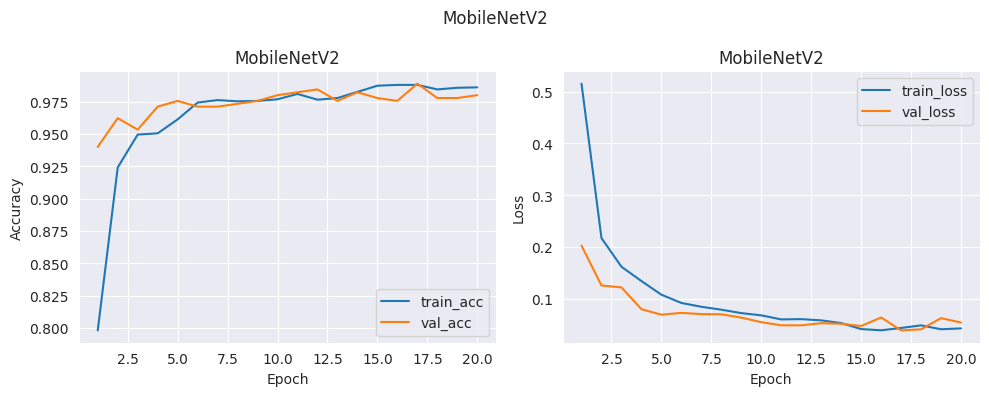

In [57]:
# Plot MobileNetV2 training curves
# Visualize MobileNetV2 accuracy and loss progression.
plot_history("mobilenet_v2", title="MobileNetV2")


### MobileNetV2 — save weights
Save the trained MobileNetV2 model to disk.

In [58]:
# Save MobileNetV2 model
from pathlib import Path

# Persist MobileNetV2 weights for reuse.
Path("models").mkdir(exist_ok=True)
mobilenet_model.save("models/mobilenet_v2.h5")
print("Saved MobileNetV2 to models/mobilenet_v2.h5")


Saved MobileNetV2 to models/mobilenet_v2.h5


## Vision Transformer (Keras)
Compact ViT classifier: define the transformer, train/evaluate, plot learning curves, and save the weights.

### Vision Transformer — define architecture
Build a compact ViT: patch embedding, transformer blocks, and classifier head.

In [59]:
# Define Vision Transformer (Keras)
from tensorflow.keras import layers

# Builds a compact Vision Transformer classifier with patch embedding and transformer blocks.
def make_vit_keras():
    patch_size = 16
    projection_dim = 64
    transformer_layers = 6
    num_heads = 4
    dropout_rate = 0.1
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    def vit_mlp(x, hidden_units, dropout):
        for units in hidden_units:
            x = layers.Dense(units, activation="gelu")(x)
            x = layers.Dropout(dropout)(x)
        return x

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(filters=projection_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(inputs)
    x = layers.Reshape((num_patches, projection_dim))(x)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = x + pos_embedding

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate)(x1, x1)
        x2 = layers.Add()([attn_output, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = vit_mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout=dropout_rate)
        x = layers.Add()([x3, x2])

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs=inputs, outputs=outputs, name="ViT_Keras")


### Vision Transformer — train and evaluate
Instantiate the ViT model, run one placeholder epoch, and print metrics.

In [60]:
# Train Vision Transformer (Keras)
# Set placeholder epochs; increase later for real training.
epochs = 20
vit_keras_model = make_vit_keras()
vit_results = compile_and_train(vit_keras_model, "vit_keras", epochs=epochs)

# Quick view of accumulated test metrics for all trained models.
print({k: {"test_acc": round(v["test_acc"], 3), "test_loss": round(v["test_loss"], 3)} for k, v in results.items()})


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 94s 622ms/step - accuracy: 0.4001 - loss: 1.1118 - val_accuracy: 0.6400 - val_loss: 0.7479
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.6110 - loss: 0.7906 - val_accuracy: 0.6911 - val_loss: 0.6858
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.6555 - loss: 0.7315 - val_accuracy: 0.7044 - val_loss: 0.6542
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.6890 - loss: 0.6842 - val_accuracy: 0.7289 - val_loss: 0.5823
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 406ms/step - accuracy: 0.6962 - loss: 0.6588 - val_accuracy: 0.7378 - val_loss: 0.6201
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.7592 - loss: 0.5455 - val_accuracy: 0.7667 - val_loss: 0.6013
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.7832 - loss: 0.5184 - val_accuracy: 0.7889 - val_loss: 0.5489
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.8062 - loss: 0.4886 - val_accu

### Vision Transformer — plot learning curves
Plot training and validation accuracy/loss for the ViT run.

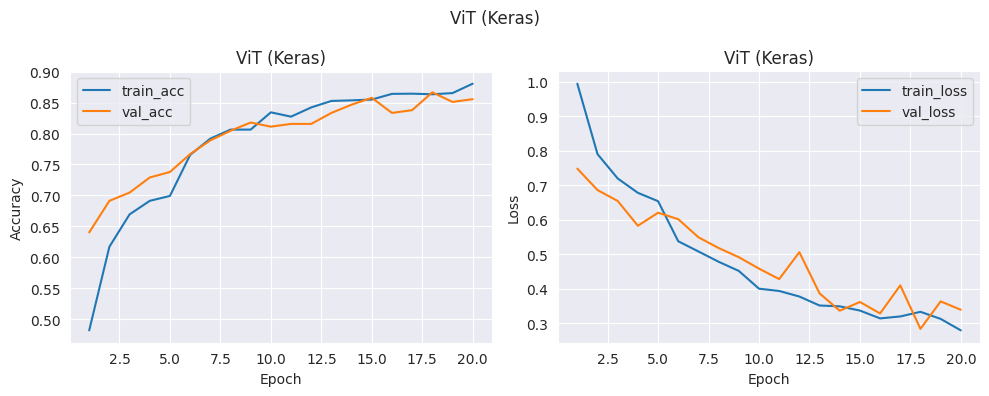

In [61]:
# Plot Vision Transformer training curves
# Uses shared helper to draw accuracy/loss for this run.
plot_history("vit_keras", title="ViT (Keras)")


### Vision Transformer — save weights
Save the trained ViT model to disk.

In [62]:
# Save Keras ViT model
from pathlib import Path

# Ensure models directory exists then save the ViT weights.
Path("models").mkdir(exist_ok=True)
vit_keras_model.save("models/vit_keras.h5")
print("Saved ViT (Keras) to models/vit_keras.h5")


Saved ViT (Keras) to models/vit_keras.h5


## Compare trained models on test metrics
Run this after training to visualize accuracy, precision, recall, F1, and macro AUC across available models.

,accuracy,precision,recall,f1,auc
model,,,,,
cnn_baseline,0.938889,0.943508,0.938889,0.938609,0.989703
efficientnet_b0,0.333333,0.111111,0.333333,0.166667,0.685338
densenet121,0.981111,0.981162,0.981111,0.981069,0.998857
vgg16,0.910000,0.909355,0.910000,0.909092,0.980956
inception_v3,0.946667,0.948140,0.946667,0.946108,0.995981
mobilenet_v2,0.977778,0.978665,0.977778,0.977762,0.998554
resnet50,0.605556,0.621051,0.605556,0.542158,0.827672
vit_keras,0.867778,0.868538,0.867778,0.865049,0.974287


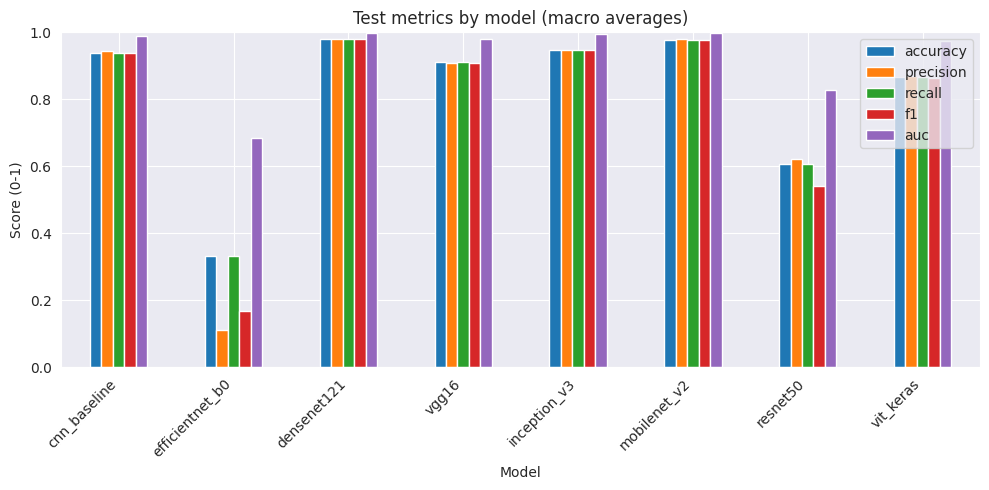

In [63]:
# Gather trained models in the current session and visualize macro metrics.
trained_models = {}
for name, var in [
    ("cnn_baseline", "cnn_model"),
    ("efficientnet_b0", "EffNetB0_model"),
    ("densenet121", "densenet_model"),
    ("vgg16", "vgg16_model"),
    ("inception_v3", "inception_model"),
    ("mobilenet_v2", "mobilenet_model"),
    ("resnet50", "resnet_model"),
    ("vit_keras", "vit_keras_model"),
]:
    if var in globals():
        trained_models[name] = globals()[var]

metrics_df = evaluate_and_plot(trained_models)

## IEEE architecture visualizations
Generate publication-ready architecture diagrams for all notebook models.

Exports:
`outputs/architectures/*.png`

This cell expects the model builder functions to already be defined.


 GENERATING ARCHITECTURE VISUALIZATIONS WITH IEEE STANDARDS

Output directory: /kaggle/working/outputs/architectures

 ARCHITECTURE VISUALIZATIONS - IEEE COMPLIANT PNG EXPORT

Generating architecture diagrams for all notebook models...
Each figure saved as: fig_<model>_arch.png (300 DPI)

1. CNN Baseline architecture visualization
--------------------------------------------------------------------------------
Source: builder:make_cnn_baseline
PNG: fig_cnn_baseline_arch.png (192.4 KB)
Export mode: dot_png
CNN Baseline visualization complete

2. EfficientNetB0 architecture visualization
--------------------------------------------------------------------------------
Source: builder:make_efficientnet_b0
PNG: fig_efficientnet_b0_arch.png (119.2 KB)
Export mode: dot_png
EfficientNetB0 visualization complete

3. DenseNet121 architecture visualization
--------------------------------------------------------------------------------
Source: builder:make_densenet121
PNG: fig_densenet121_arch.p

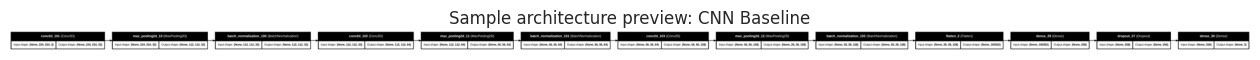

In [64]:
# IEEE-compliant architecture export for all models in this notebook (PNG only)
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import model_to_dot, plot_model

print("\n" + "=" * 80)
print(" GENERATING ARCHITECTURE VISUALIZATIONS WITH IEEE STANDARDS")
print("=" * 80)

output_base = Path("outputs/architectures")
output_base.mkdir(parents=True, exist_ok=True)
print(f"\nOutput directory: {output_base.resolve()}")

# Model metadata: builder function name and fallback saved-model path.
model_specs = [
    ("CNN Baseline", "make_cnn_baseline", Path("models/cnn_baseline.h5"), "fig_cnn_baseline_arch"),
    ("EfficientNetB0", "make_efficientnet_b0", Path("models/efficientnet_b0.h5"), "fig_efficientnet_b0_arch"),
    ("DenseNet121", "make_densenet121", Path("models/densenet121.h5"), "fig_densenet121_arch"),
    ("VGG16", "make_vgg16", Path("models/vgg16.h5"), "fig_vgg16_arch"),
    ("InceptionV3", "make_inception_v3", Path("models/inception_v3.h5"), "fig_inception_v3_arch"),
    ("MobileNetV2", "make_mobilenet_v2", Path("models/mobilenet_v2.h5"), "fig_mobilenet_v2_arch"),
    ("ResNet50", "make_resnet50", Path("models/resnet50.h5"), "fig_resnet50_arch"),
    ("Vision Transformer (Keras)", "make_vit_keras", Path("models/vit_keras.h5"), "fig_vit_keras_arch"),
]


def infer_shape_and_classes():
    probe_path = Path("models/cnn_baseline.h5")
    if probe_path.exists():
        probe = tf.keras.models.load_model(probe_path, compile=False)
        shape = tuple(probe.input_shape[1:])
        classes = int(probe.output_shape[-1])
        return shape, classes
    return (224, 224, 3), 3


def build_vit_fallback(input_shape, num_classes):
    patch_size = 16
    projection_dim = 64
    transformer_layers = 6
    num_heads = 4
    dropout_rate = 0.1
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    def mlp(x, hidden_units, dropout):
        for units in hidden_units:
            x = layers.Dense(units, activation="gelu")(x)
            x = layers.Dropout(dropout)(x)
        return x

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(filters=projection_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(inputs)
    x = layers.Reshape((num_patches, projection_dim))(x)
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = x + pos_embedding

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate)(x1, x1)
        x2 = layers.Add()([attn_output, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout=dropout_rate)
        x = layers.Add()([x3, x2])

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="ViT_Keras_fallback")


def resolve_model(model_name: str, builder_name: str, fallback_model_path: Path):
    # Prefer in-memory builder (if previously defined), otherwise load saved model from disk.
    if builder_name in globals() and callable(globals()[builder_name]):
        return globals()[builder_name](), f"builder:{builder_name}"

    if fallback_model_path.exists():
        try:
            return tf.keras.models.load_model(fallback_model_path, compile=False), f"saved_model:{fallback_model_path.name}"
        except Exception as load_err:
            if "Vision Transformer" in model_name:
                input_shape, num_classes = infer_shape_and_classes()
                model = build_vit_fallback(input_shape=input_shape, num_classes=num_classes)
                return model, "vit_fallback:reconstructed"
            raise RuntimeError(
                f"Failed to load fallback model '{fallback_model_path}': {load_err}"
            ) from load_err

    if "Vision Transformer" in model_name:
        input_shape, num_classes = infer_shape_and_classes()
        model = build_vit_fallback(input_shape=input_shape, num_classes=num_classes)
        return model, "vit_fallback:reconstructed"

    raise NameError(
        f"Builder '{builder_name}' is not defined and fallback file '{fallback_model_path}' was not found."
    )


def _shape_to_text(shape_obj):
    if shape_obj is None:
        return "?"
    if isinstance(shape_obj, list):
        return " / ".join(str(s) for s in shape_obj)
    return str(shape_obj)


def _human_params(params: int):
    if params >= 1_000_000:
        return f"{params / 1_000_000:.1f}M"
    if params >= 1_000:
        return f"{params / 1_000:.1f}K"
    return str(params)


def _stage_from_layer(layer):
    cls = layer.__class__.__name__
    cls_low = cls.lower()
    name_low = layer.name.lower()

    if cls == "InputLayer":
        return "Input", "Input tensor"

    if cls in {"Embedding", "Reshape"} or "patch" in name_low:
        return "Tokenization", "Patch/token embedding"

    if "attention" in cls_low or "transformer" in name_low or cls == "LayerNormalization":
        return "Attention Blocks", "Self-attention + normalization"

    if cls in {
        "Conv2D",
        "DepthwiseConv2D",
        "SeparableConv2D",
        "BatchNormalization",
        "Activation",
        "ReLU",
        "Add",
        "Concatenate",
        "MaxPooling2D",
        "AveragePooling2D",
    }:
        return "Feature Extractor", "Convolutional feature learning"

    if cls in {"GlobalAveragePooling2D", "GlobalAveragePooling1D", "Flatten"}:
        return "Feature Aggregation", "Spatial-to-vector aggregation"

    if cls == "Dense":
        act = getattr(getattr(layer, "activation", None), "__name__", "")
        if act == "softmax":
            return "Output", "Class probabilities"
        return "Classifier", "Dense prediction head"

    if cls == "Dropout":
        return "Classifier", "Regularization"

    return "Processing", "Auxiliary operations"


def _build_stage_summary(model):
    stage_flow = []
    for lyr in model.layers:
        title, subtitle = _stage_from_layer(lyr)
        item = {
            "title": title,
            "subtitle": subtitle,
            "count": 1,
            "params": lyr.count_params() if hasattr(lyr, "count_params") else 0,
            "out_shape": _shape_to_text(getattr(lyr, "output_shape", None)),
        }
        if stage_flow and stage_flow[-1]["title"] == title:
            stage_flow[-1]["count"] += 1
            stage_flow[-1]["params"] += item["params"]
            stage_flow[-1]["out_shape"] = item["out_shape"]
        else:
            stage_flow.append(item)

    # Collapse repeated stage names into a concise sequential pipeline.
    compact = []
    stage_index = {}
    for stage in stage_flow:
        key = stage["title"]
        if key not in stage_index:
            stage_index[key] = len(compact)
            compact.append(stage)
        else:
            idx = stage_index[key]
            compact[idx]["count"] += stage["count"]
            compact[idx]["params"] += stage["params"]
            compact[idx]["out_shape"] = stage["out_shape"]

    return compact if compact else [{"title": "Model", "subtitle": "Sequential pipeline", "count": 1, "params": int(model.count_params()), "out_shape": "?"}]


def draw_block_architecture(model, png_path: Path):
    # Build a wide, stage-based sequential diagram with fewer high-level steps.
    stages = _build_stage_summary(model)
    n = max(1, len(stages))

    color_map = {
        "Input": "#C7D4DC",
        "Tokenization": "#BFD9EA",
        "Feature Extractor": "#A7C9DE",
        "Attention Blocks": "#F0D9A6",
        "Feature Aggregation": "#BFDDBF",
        "Classifier": "#D6C4E5",
        "Output": "#EAA9B3",
        "Processing": "#D8DEE2",
    }

    step_x = 4.2
    box_w = 3.1
    box_h = 3.8
    fig_w = min(44, max(20, n * 4.3))
    fig_h = 8.2
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, n * step_x + 1.8)
    ax.set_ylim(0, 11)
    ax.axis("off")

    ax.text(0.6, 10.2, f"{model.name} architecture", fontsize=18, fontweight="bold", ha="left", va="center")

    y = 5.9
    for i, stage in enumerate(stages):
        x = 0.8 + i * step_x
        fc = color_map.get(stage["title"], "#E0E0E0")

        rect = FancyBboxPatch(
            (x, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.04,rounding_size=0.12",
            linewidth=1.6,
            edgecolor="#202124",
            facecolor=fc,
            alpha=0.96,
        )
        ax.add_patch(rect)

        ax.text(x + box_w / 2, y + 1.0, stage["title"], ha="center", va="center", fontsize=11, fontweight="bold")
        ax.text(x + box_w / 2, y + 0.35, stage["subtitle"], ha="center", va="center", fontsize=9)
        ax.text(x + box_w / 2, y - 0.3, f"layers: {stage['count']}", ha="center", va="center", fontsize=8.8)
        ax.text(x + box_w / 2, y - 0.9, f"params: {_human_params(stage['params'])}", ha="center", va="center", fontsize=8.8)
        ax.text(x + box_w / 2, y - 1.45, f"out: {stage['out_shape']}", ha="center", va="center", fontsize=8)

        if i < n - 1:
            x2 = 0.8 + (i + 1) * step_x
            ax.annotate(
                "",
                xy=(x2 - 0.18, y),
                xytext=(x + box_w + 0.12, y),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="#1F1F1F"),
            )

    ax.text(0.6, 0.9, f"Total Parameters: {_human_params(int(model.count_params()))}", fontsize=12, fontweight="bold", ha="left", va="center")
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def export_architecture_png(model, base_filename: str):
    """Export architecture as PNG (300 DPI) with robust visual fallback."""
    png_path = output_base / f"{base_filename}.png"
    if png_path.exists():
        png_path.unlink()

    # 1) DOT export (requires Graphviz binaries), 2) plot_model, 3) custom block diagram.
    try:
        dot = model_to_dot(
            model,
            show_shapes=True,
            show_dtype=False,
            show_layer_names=True,
            rankdir="LR",
            expand_nested=True,
            dpi=300,
        )
        dot.write_png(str(png_path))
        export_mode = "dot_png"
    except Exception as dot_err:
        try:
            plot_model(
                model,
                to_file=str(png_path),
                show_shapes=True,
                show_layer_names=True,
                expand_nested=True,
                dpi=300,
            )
            export_mode = f"plot_model_png_fallback ({type(dot_err).__name__})"
        except Exception as plot_err:
            draw_block_architecture(model, png_path)
            export_mode = f"block_diagram_fallback ({type(dot_err).__name__}; {type(plot_err).__name__})"

    if not png_path.exists() or png_path.stat().st_size == 0:
        draw_block_architecture(model, png_path)
        export_mode = f"block_diagram_fallback_after_empty ({export_mode})"

    return png_path, export_mode


print("\n" + "=" * 80)
print(" ARCHITECTURE VISUALIZATIONS - IEEE COMPLIANT PNG EXPORT")
print("=" * 80)
print("\nGenerating architecture diagrams for all notebook models...")
print("Each figure saved as: fig_<model>_arch.png (300 DPI)")

generated_files = []

for i, (model_name, builder_name, fallback_model_path, base_filename) in enumerate(model_specs, 1):
    print(f"\n{i}. {model_name} architecture visualization")
    print("-" * 80)

    try:
        model, model_source = resolve_model(model_name, builder_name, fallback_model_path)
        png_path, export_mode = export_architecture_png(model, base_filename)

        png_size_kb = png_path.stat().st_size / 1024 if png_path.exists() else 0.0

        generated_files.append(
            {
                "model": model_name,
                "builder": builder_name,
                "source": model_source,
                "base_filename": base_filename,
                "png": str(png_path),
                "png_kb": round(png_size_kb, 1),
                "export_mode": export_mode,
                "status": "OK",
            }
        )

        print(f"Source: {model_source}")
        print(f"PNG: {png_path.name} ({png_size_kb:.1f} KB)")
        print(f"Export mode: {export_mode}")
        print(f"{model_name} visualization complete")

    except Exception as e:
        generated_files.append(
            {
                "model": model_name,
                "builder": builder_name,
                "base_filename": base_filename,
                "status": "ERROR",
                "error": str(e),
            }
        )
        print(f"Error: {e}")

print("\n" + "=" * 80)
print(" STEP 2: MODEL ARCHITECTURE EXPLANATIONS")
print("=" * 80)

explanations = {
    "CNN Baseline": "Three Conv-BN-MaxPool stages + dense head. Strong baseline with low complexity.",
    "EfficientNetB0": "Compound-scaled pretrained backbone, frozen features, lightweight classification head.",
    "DenseNet121": "Dense connectivity improves feature reuse and gradient flow with a compact parameter budget.",
    "VGG16": "Deep stack of 3x3 convolutions. Simple and stable transfer learning baseline.",
    "InceptionV3": "Multi-branch convolutions capture multi-scale patterns efficiently.",
    "MobileNetV2": "Depthwise separable convolutions + inverted residuals for lightweight deployment.",
    "ResNet50": "Residual skip connections support deeper optimization and robust feature extraction.",
    "Vision Transformer (Keras)": "Patch embedding + multi-head self-attention blocks for global context modeling.",
}

for i, (model_name, _, _, _) in enumerate(model_specs, 1):
    print(f"\n{i}. {model_name}")
    print("-" * 80)
    print(explanations.get(model_name, "Architecture details not specified."))

print("\n" + "=" * 80)
print(" ARCHITECTURE VISUALIZATION GENERATION COMPLETE")
print("=" * 80)

ok_count = sum(1 for item in generated_files if item["status"] == "OK")
print(f"\nSummary:")
print(f"Visualizations generated: {ok_count}/{len(model_specs)}")
print(f"Models documented: {len(model_specs)}")
print(f"Output directory: {output_base.resolve()}")

print("\nGenerated files:")
for idx, item in enumerate(generated_files, 1):
    if item["status"] == "OK":
        print(f"{idx}. {item['model']}")
        print(f"   PNG: {Path(item['png']).name}")
        print(f"   Source: {item.get('source', 'unknown')}")
        print(f"   Mode: {item.get('export_mode', 'unknown')}")
    else:
        print(f"{idx}. {item['model']} - ERROR: {item.get('error', 'Unknown error')}")

# Optional preview of one generated figure if available.
ok_items = [item for item in generated_files if item["status"] == "OK"]
if ok_items:
    sample_png = ok_items[0]["png"]
    if sample_png and Path(sample_png).exists():
        with Image.open(sample_png) as img:
            # Use a downscaled in-memory preview to avoid notebook MemoryError on very large PNGs.
            preview = img.copy()
            preview.thumbnail((2400, 1400), Image.Resampling.LANCZOS)
            plt.figure(figsize=(16, 8))
            plt.imshow(preview)
            plt.axis("off")
            plt.title(f"Sample architecture preview: {ok_items[0]['model']}")
            plt.show()